In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# Import the data
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

In [7]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
X.shape

(20640, 8)

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [13]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: target, dtype: float64

In [14]:
# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16512, 8)
X_test : (4128, 8)
y_train: (16512,)
y_test : (4128,)


In [17]:
# Create the model
model = DecisionTreeRegressor(criterion='squared_error', max_depth=5, random_state=42)

# Train the model
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [18]:
# Make predictions
y_pred = model.predict(X_test)

In [25]:
# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error  :", round(mse,2))
print("Root Mean Squared Error:", round(rmse,2))
print("R² Score            :", round(r2,4))

Mean Absolute Error : 0.52
Mean Squared Error  : 0.52
Root Mean Squared Error: 0.72
R² Score            : 0.5997


In [26]:
# Compare the model
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})

comparison.head(10)

,Actual,Predicted
0,0.47700,1.168573
1,0.45800,1.271581
2,5.00001,3.199582
3,2.18600,2.204763
4,2.78000,1.642797
5,1.58700,2.337900
6,1.98200,1.920621
7,1.57500,1.642797
8,3.40000,2.375496
9,4.46600,4.778789


In [27]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns, 
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,MedInc,0.771212
5,AveOccup,0.128407
1,HouseAge,0.041621
2,AveRooms,0.031261
6,Latitude,0.022049
4,Population,0.002485
7,Longitude,0.002097
3,AveBedrms,0.000869


### Hyperparameter Tuning with GridSearchCV

In [39]:
# Testing with Other parameter using the parameter Grid
para_grid = {
    'max_depth' : [2,4,6,8,10, None],
    'criterion' : ['squared_error','absolute_error'],
    'max_features' : [0.25, 0.5, 1],
    'min_samples_split' : [2,5,10]
}

para_grid

{'max_depth': [2, 4, 6, 8, 10, None],
 'criterion': ['squared_error', 'absolute_error'],
 'max_features': [0.25, 0.5, 1],
 'min_samples_split': [2, 5, 10]}

In [40]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator = DecisionTreeRegressor(random_state=42),
    param_grid = para_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [41]:
# Train the model
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'absolute_error'],
                         'max_depth': [2, 4, 6, 8, 10, None],
                         'max_features': [0.25, 0.5, 1],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [43]:
# Find the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'absolute_error', 'max_depth': 10, 'max_features': 0.5, 'min_samples_split': 2}


### Evaluate the tuned model
```GridSearchCV``` automatically refits the best model by default!

In [44]:
best_model = grid_search.best_estimator_

In [46]:
# Make predictions
y_pred_tuned = best_model.predict(X_test)

In [48]:
tuned_r2 = r2_score(y_test, y_pred_tuned)
print('Tuned Model R2 Score:', tuned_r2)

Tuned Model R2 Score: 0.7040767055818177


In [50]:
# Final Comparison

print("Original Model R² :", round(r2,4))
print("Tuned Model R²    :", round(tuned_r2,4))

Original Model R² : 0.5997
Tuned Model R²    : 0.7041


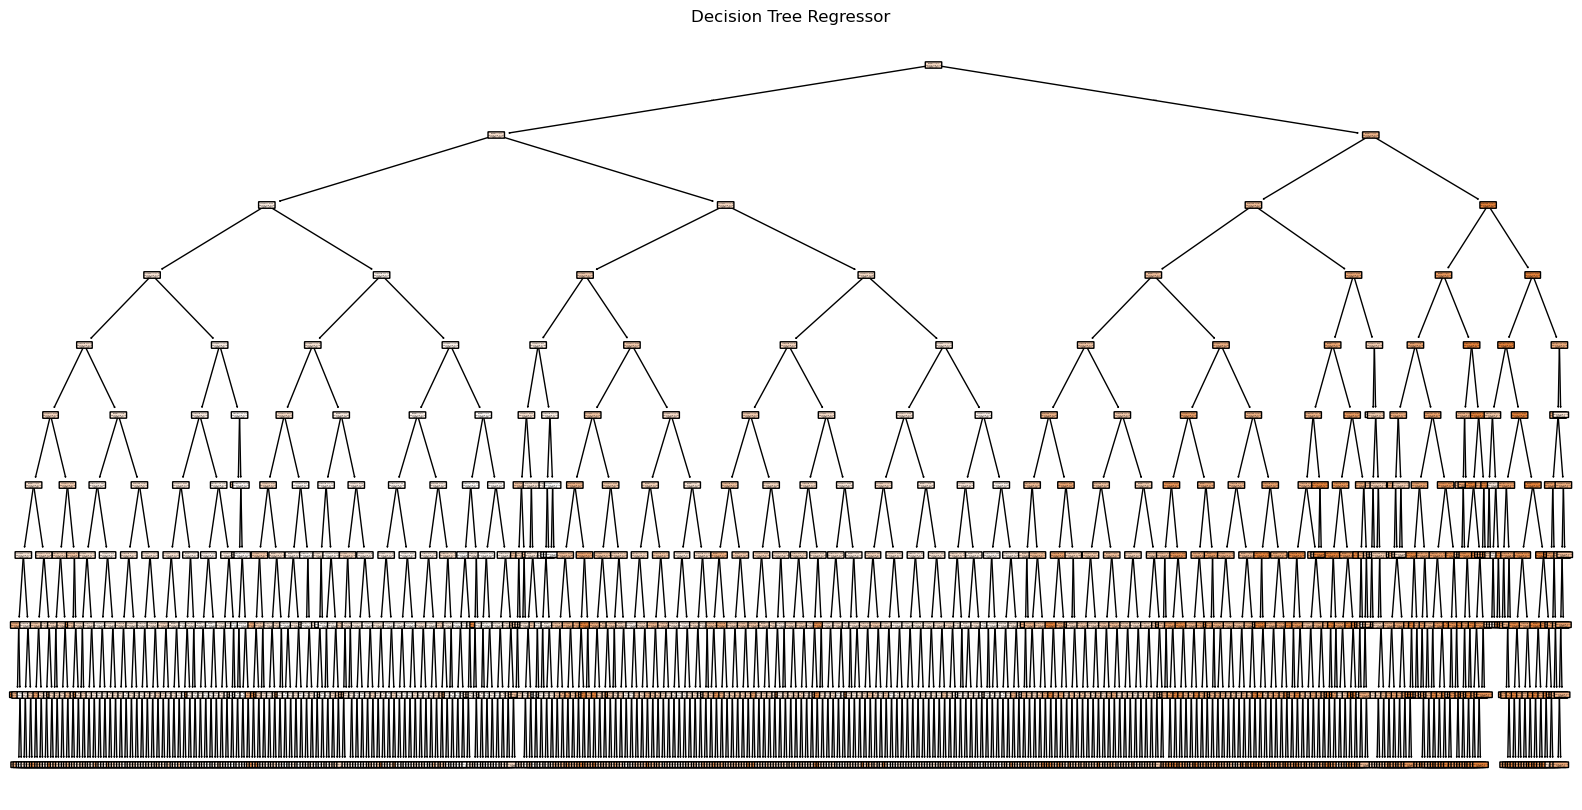

In [55]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    precision=2,
)

plt.title("Decision Tree Regressor")
plt.show()

> As the tree is too huge,
 Since ```max_depth=5``` can still produce a fairly large visualization, you can display only the first few levels:

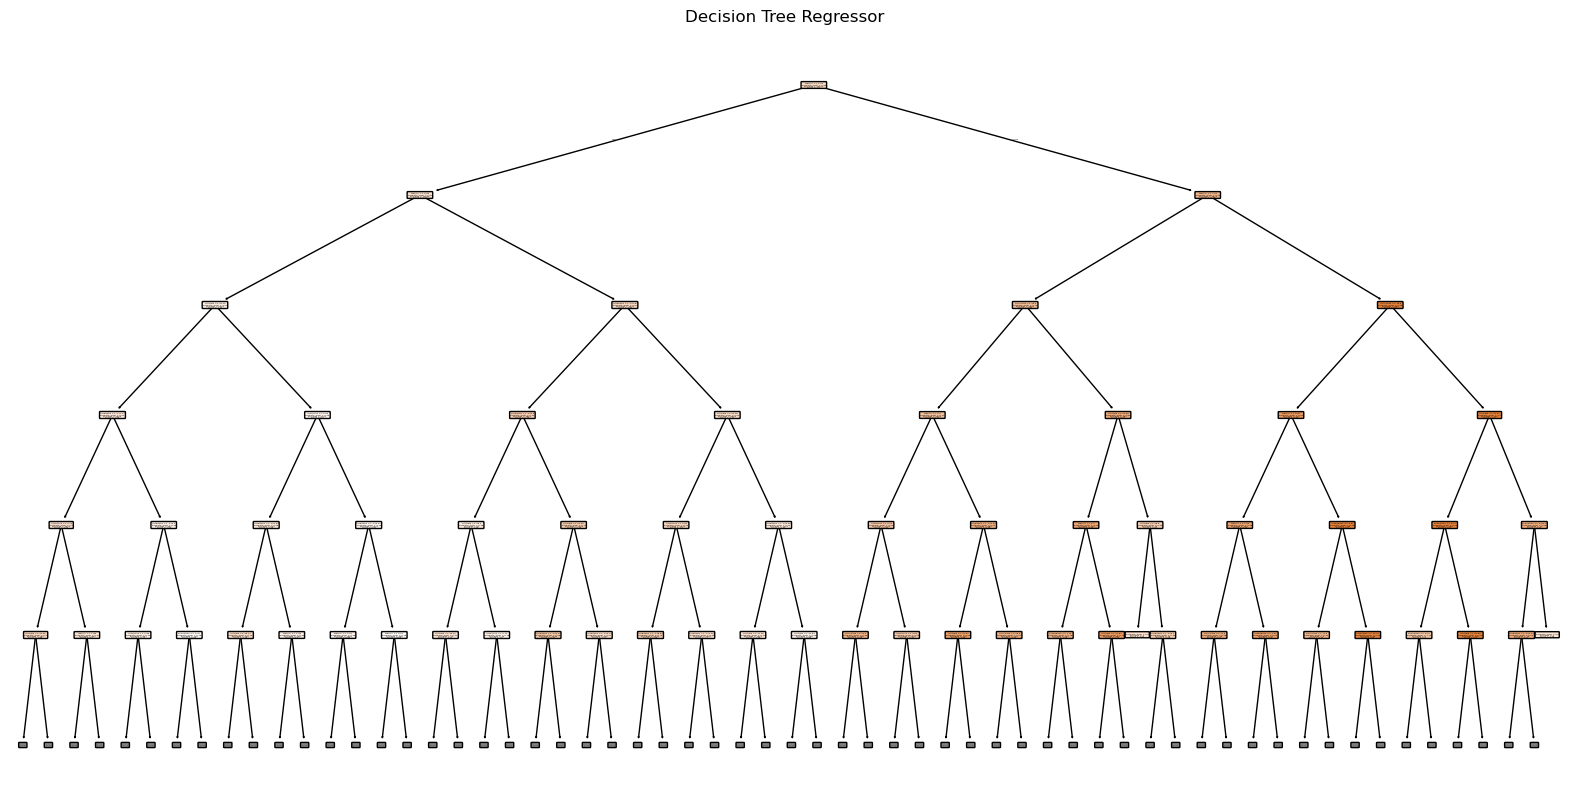

In [56]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    precision=2,
    max_depth = 5
)

plt.title("Decision Tree Regressor")
plt.show()